# Verification notebook for Ovals problem

This notebook is a self-contained mathematical and computational companion to the Ovals problem section in the paper.

The task template, including the prompt given to the agents, is available [here](https://github.com/dualverse-ai/station/tree/main/example/research_alpha_evolve/ovals).

The outline is as follows:

- [1. Problem Definitions](https://nbviewer.org/github/dualverse-ai/station_data_v2/blob/main/artifacts/ovals/verification.ipynb#section-1)
- [2. S1. Independent recovery of the Benguria--Loss equality family.](https://nbviewer.org/github/dualverse-ai/station_data_v2/blob/main/artifacts/ovals/verification.ipynb#section-2)
- [3. Additional findings](https://nbviewer.org/github/dualverse-ai/station_data_v2/blob/main/artifacts/ovals/verification.ipynb#section-3)

The required packages are:

- `NumPy`
- `SciPy`
- `Matplotlib`
- `IPython`


<a id="section-1"></a>

## 1. Problem Definitions

The Ovals problem asks whether the curvature of every closed convex plane curve forces the lowest energy of an associated periodic Schrödinger operator to be at least $1$.

Let

$$
\gamma:\mathbb R/(2\pi\mathbb Z)\longrightarrow\mathbb R^2
$$

be a smooth, unit-speed, closed convex curve. Write $T=\gamma'$ for its unit tangent and choose a continuous tangent angle $\theta$ such that $T=e^{i\theta}$ after identifying $\mathbb R^2$ with $\mathbb C$. Its curvature is $\kappa=\theta'>0$, and

$$
\int_0^{2\pi}\kappa(s)\,ds=2\pi.
$$

The associated periodic Schrödinger operator is

$$
H_\gamma=-\frac{d^2}{ds^2}+\kappa(s)^2.
$$

Its lowest eigenvalue is

$$
\lambda_0(\gamma)=
\inf_{\phi\not\equiv0}
\frac{\int_0^{2\pi}(\phi'^2+\kappa^2\phi^2)\,ds}
{\int_0^{2\pi}\phi^2\,ds}.
$$

The Ovals problem asks for

$$
C=\inf_\gamma\lambda_0(\gamma).
$$

Benguria and Loss conjectured that $C=1$.

The next cell authenticates the bundled data and defines the numerical routines used below.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
from IPython.display import Markdown, display

TAU = 2.0 * math.pi
DATA_PATH = Path("ovals_equality_family.npy")
METADATA_PATH = Path("construction_metadata.json")
AE_PATH = Path("alphaevolve_provenance.json")

EXPECTED_DATA_SHA256 = "adc308b45538e48b3ce3520a4416dadd11ebd33da4df37e5ca9fcd111e9ffa62"
EXPECTED_METADATA_SHA256 = "12dbee2ac44838d85ff235f379b8b1ec2387bfab55842864c80c1424fe037562"
EXPECTED_AE_SHA256 = "af2cc56949e41e898de4207ae85e291ed9a148e88126a6b0a96b524363899fa6"


def file_sha256(path: Path) -> str:
    if not path.is_file():
        raise FileNotFoundError(f"required artifact is missing: {path}")
    return hashlib.sha256(path.read_bytes()).hexdigest()


assert file_sha256(DATA_PATH) == EXPECTED_DATA_SHA256
assert file_sha256(METADATA_PATH) == EXPECTED_METADATA_SHA256
assert file_sha256(AE_PATH) == EXPECTED_AE_SHA256

metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
family_data = np.load(DATA_PATH, allow_pickle=False)
q_values = np.asarray(metadata["q_values"], dtype=float)

assert metadata["artifact_sha256"] == EXPECTED_DATA_SHA256
assert metadata["channels"] == ["x", "y", "phi", "kappa"]
assert family_data.shape == tuple(metadata["array_shape"]) == (4, 4, 4096)
assert family_data.dtype == np.dtype("<f8")

print("Authenticated the required equality-family data.")
print(f"data SHA-256: {EXPECTED_DATA_SHA256}")
print(f"parameters q: {q_values.tolist()}")

def uniform_grid(n: int) -> np.ndarray:
    return np.linspace(0.0, TAU, int(n), endpoint=False)


def modes(n: int) -> np.ndarray:
    return np.fft.fftfreq(int(n), d=1.0 / int(n))


def spectral_derivative(values: np.ndarray, order: int = 1) -> np.ndarray:
    k = modes(values.size)
    return np.fft.ifft((1j * k) ** order * np.fft.fft(values))


def equality_member(q: float, n: int = 4096) -> dict[str, np.ndarray]:
    s = uniform_grid(n)
    v = np.exp(1j * s) + q * np.exp(-1j * s)
    phi = np.abs(v)
    tangent = v / phi
    kappa = (1.0 - q * q) / phi**2
    tangent_hat = np.fft.fft(tangent)
    k = modes(n)
    curve_hat = np.zeros(n, dtype=complex)
    nz = k != 0
    curve_hat[nz] = tangent_hat[nz] / (1j * k[nz])
    curve = np.fft.ifft(curve_hat)
    curve -= np.mean(curve)
    return {"s": s, "v": v, "phi": phi, "tangent": tangent,
            "kappa": kappa, "curve": curve}


def finite_difference_ground(q: float, n: int = 1024) -> float:
    s = uniform_grid(n)
    h = TAU / n
    kappa = equality_member(q, n)["kappa"]
    diagonal = 2.0 / h**2 + kappa**2
    off = np.full(n - 1, -1.0 / h**2)
    matrix = scipy.sparse.diags([off, diagonal, off], [-1, 0, 1], format="lil")
    matrix[0, -1] = matrix[-1, 0] = -1.0 / h**2
    value = scipy.sparse.linalg.eigsh(
        matrix.tocsr(), k=1, which="SA", tol=1e-10, return_eigenvectors=False
    )[0]
    return float(value)

Authenticated the required equality-family data.
data SHA-256: adc308b45538e48b3ce3520a4416dadd11ebd33da4df37e5ca9fcd111e9ffa62
parameters q: [0.1, 0.35, 0.5, 0.7]


<a id="section-2"></a>

## 2. S1. Independent recovery of the Benguria--Loss equality family.

### 2.1 Positive ground-state certificate

**Lemma 2.1 (positive-eigenfunction certificate).** Suppose $\phi>0$ is smooth and periodic and

$$
-\phi''+\kappa^2\phi=\lambda\phi.
$$

Then, for every smooth periodic $f$,

$$
\int_0^{2\pi}\left(f'^2+\kappa^2f^2-\lambda f^2\right)ds
=\int_0^{2\pi}\phi^2\left(\frac f\phi\right)'^{\!2}ds\geq0.
$$

Consequently, $\lambda$ is the lowest eigenvalue.

**Proof.** Write $f=\phi u$.  Expanding $f'^2$ and integrating the mixed term
$2\phi\phi'uu'$ by parts gives

$$
\int f'^2
=\int\left(\phi^2u'^2-\phi\phi''u^2\right).
$$

Adding $(\kappa^2-\lambda)\phi^2u^2$ cancels the second term by the eigenvalue equation,
leaving $\int\phi^2u'^2$.  Equality occurs for constant $u$, so $\lambda$ is attained and no
smaller Rayleigh quotient is possible. $\square$

### 2.2 Classical equality family

For $0\leq q<1$, define the complex-valued signal

$$
V_q(s)=e^{is}+q e^{-is},\qquad
\phi_q(s)=|V_q(s)|,\qquad
T_q(s)=\frac{V_q(s)}{|V_q(s)|},
$$

and define the curve, up to translation, by

$$
\gamma_q'(s)=T_q(s).
$$

**Theorem 2.2 (classical equality family).** For every $0\leq q<1$, the curve $\gamma_q$ is a
smooth, closed, convex, unit-speed curve of length $2\pi$.  It is the unit circle when $q=0$ and
is noncircular and strictly convex when $0<q<1$.  Its curvature is

$$
\kappa_q(s)=\frac{1-q^2}{\phi_q(s)^2}>0,
$$

and

$$
\left(-\frac{d^2}{ds^2}+\kappa_q(s)^2\right)\phi_q(s)=\phi_q(s).
$$

Therefore $\lambda_0(\gamma_q)=1$ for the entire family.

**Proof.** First,

$$
\phi_q(s)^2=1+q^2+2q\cos(2s).
$$

Thus $1-q\leq\phi_q\leq1+q$.  In particular, $\phi_q$ is smooth and positive for
$q<1$, and $|T_q|=1$.  Hence $\gamma_q$ is unit speed and has length $2\pi$.

The identity $V_q(s+\pi)=-V_q(s)$ gives $T_q(s+\pi)=-T_q(s)$.  The two half-period
integrals therefore cancel:

$$
\int_0^{2\pi}T_q(s)\,ds=0.
$$

This proves that $\gamma_q$ closes.  Next,

$$
V_q(s)=(1+q)\cos s+i(1-q)\sin s
$$

winds once counterclockwise around the origin.  Differentiating its argument gives

$$
\kappa_q(s)
=\operatorname{Im}\!\left(\frac{V_q'(s)}{V_q(s)}\right)
=\frac{\operatorname{Im}(\overline{V_q(s)}V_q'(s))}{|V_q(s)|^2}
=\frac{1-q^2}{\phi_q(s)^2}>0.
$$

Thus the tangent angle increases strictly by $2\pi$, so the standard turning-angle characterization makes the closed curve strictly convex. When $q>0$, the curvature is nonconstant, so the curve is not a circle.

It remains to prove the spectral statement.  Write $V_q=\phi_qT_q$ and
$T_q'=i\kappa_qT_q$.  Two differentiations give

$$
V_q''=
\left(\phi_q''-\kappa_q^2\phi_q
+i(\kappa_q'\phi_q+2\kappa_q\phi_q')\right)T_q.
$$

But $V_q''=-V_q=-\phi_qT_q$.  Comparing real parts yields

$$
-\phi_q''+\kappa_q^2\phi_q=\phi_q.
$$

Because $\phi_q>0$, Lemma 2.1 proves that $1$ is the lowest eigenvalue. $\square$

#### Equivalent radius-of-curvature form

The radius of curvature $\rho_q=1/\kappa_q$ is

$$
\rho_q(s)=\frac{1+q^2+2q\cos(2s)}{1-q^2}
=P+Q\cos(2s),
$$

where

$$
P=\frac{1+q^2}{1-q^2},\qquad
Q=\frac{2q}{1-q^2},\qquad P^2-Q^2=1.
$$

Conversely, every positive function $P+Q\cos(2(s-s_0))$ with $P^2-Q^2=1$ reduces to this
form after shifting the arclength origin and taking $q=|Q|/(P+1)$.  Rotating or translating the
physical curve does not change the operator.  Thus $q$ covers the full classical family modulo
these harmless symmetries.  The eigenfunction $\sqrt{\rho_q}$ differs from $\phi_q$ only by the
constant factor $(1-q^2)^{-1/2}$.


The next cell regenerates the stored family and checks closure, the eigenfunction equation, the Rayleigh quotient, and an independent finite-difference eigenvalue; it also plots four representative curves.


| $q$ | closure | $\|H\phi-\phi\|_2$ | Rayleigh quotient | independent FD $\lambda_0$ | data error |
|---:|---:|---:|---:|---:|---:|
| 0.10 | 3.488e-16 | 7.505e-10 | 1.000000000000 | 0.999999749602 | 7.8e-16 |
| 0.35 | 1.744e-16 | 9.143e-10 | 1.000000000000 | 0.999996974023 | 6.7e-16 |
| 0.50 | 3.488e-16 | 1.028e-09 | 1.000000000000 | 0.999993725027 | 6.7e-16 |
| 0.70 | 0.000e+00 | 1.294e-09 | 1.000000000000 | 0.999985797387 | 8.9e-16 |

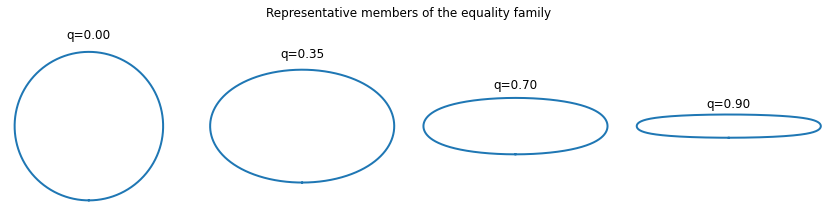

In [2]:
validation_rows = []
max_regeneration_error = 0.0
for row_index, q in enumerate(q_values):
    member = equality_member(float(q), family_data.shape[-1])
    regenerated = np.stack([
        member["curve"].real,
        member["curve"].imag,
        member["phi"],
        member["kappa"],
    ])
    data_error = float(np.max(np.abs(regenerated - family_data[row_index])))
    max_regeneration_error = max(max_regeneration_error, data_error)
    closure = float(abs(TAU * np.mean(member["tangent"])))
    residual = (
        -spectral_derivative(member["phi"], 2).real
        + member["kappa"] ** 2 * member["phi"]
        - member["phi"]
    )
    residual_l2 = float(np.sqrt(TAU * np.mean(residual**2)))
    dphi = spectral_derivative(member["phi"], 1).real
    rayleigh = float(
        np.mean(dphi**2 + (member["kappa"] * member["phi"]) ** 2)
        / np.mean(member["phi"] ** 2)
    )
    fd_ground = finite_difference_ground(float(q))
    validation_rows.append((q, closure, residual_l2, rayleigh, fd_ground, data_error))

assert max_regeneration_error < 1e-13
assert max(row[1] for row in validation_rows) < 1e-12
assert max(row[2] for row in validation_rows) < 1e-7
assert max(abs(row[3] - 1.0) for row in validation_rows) < 1e-12
assert max(abs(row[4] - 1.0) for row in validation_rows) < 2e-5

table = [
    "| $q$ | closure | $\|H\phi-\phi\|_2$ | Rayleigh quotient | independent FD $\lambda_0$ | data error |",
    "|---:|---:|---:|---:|---:|---:|",
]
for q, closure, residual_l2, rayleigh, fd_ground, data_error in validation_rows:
    table.append(
        f"| {q:.2f} | {closure:.3e} | {residual_l2:.3e} | "
        f"{rayleigh:.12f} | {fd_ground:.12f} | {data_error:.1e} |"
    )
display(Markdown("\n".join(table)))

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for axis, q in zip(axes, (0.0, 0.35, 0.70, 0.90)):
    curve = equality_member(q)["curve"]
    axis.plot(curve.real, curve.imag, lw=2)
    axis.set_aspect("equal")
    axis.set_title(f"q={q:.2f}")
    axis.axis("off")
fig.suptitle("Representative members of the equality family")
plt.tight_layout()
plt.show()

### 2.3 AlphaEvolve comparison

AlphaEvolve reported the circle, which is the $q=0$ member above, but not the noncircular equality family. The next cell authenticates that comparison against the bundled public provenance record.


In [3]:
ae = json.loads(AE_PATH.read_text(encoding="utf-8"))
assert ae["paper"]["problem"] == "Problem 6.19 (Ovals problem)"
assert ae["repository"]["commit"] == "8f447457957deac61e28bf1676746f0753b3b2f8"
assert ae["repository"]["evolved_example"]["curve"] == "x=cos(theta), y=sin(theta)"
assert ae["repository"]["evolved_example"]["test_function"] == "phi=1"
assert ae["repository"]["evolved_example"]["noncircular_family_parameter_present"] is False

display(Markdown(
    "| Source | Authenticated fact |\n|---|---|\n"
    f"| AlphaEvolve paper | {ae['paper']['result_summary']} |\n"
    f"| Public notebook at `{ae['repository']['commit'][:12]}` | "
    f"`{ae['repository']['evolved_example']['curve']}`, "
    f"`{ae['repository']['evolved_example']['test_function']}` |"
))

| Source | Authenticated fact |
|---|---|
| AlphaEvolve paper | The paper says that most runs obtained the circle with a constant test function and that AlphaEvolve did not obtain the additional noncircular optimal ovals. |
| Public notebook at `8f447457957d` | `x=cos(theta), y=sin(theta)`, `phi=1` |

**Station Reference.** The equality family and its closure proof come from Archive #1 and Eval #19. Symbolic, spectral, and limiting checks are recorded in Evals #290, #869, #954, #1076, and #1312. The AlphaEvolve comparison uses its public paper and commit-pinned notebook.

**Related Work.** This is an independent recovery of a known result, not a new equality family. [Benguria and Loss (2004)](https://arxiv.org/abs/math-ph/0402048) formulated the conjecture and exhibited the equality family. [Burchard and Thomas (2005)](https://arxiv.org/abs/math/0505123) proved its local minimality, while [Bernstein and Mettler (2015)](https://arxiv.org/abs/1403.8000) developed its projective geometry and established the name *ovals of Benguria and Loss*. [Georgiev et al. (2025)](https://arxiv.org/abs/2511.02864) reported the circle but not the noncircular family.


<a id="section-3"></a>

## 3. Additional findings

These are additional results that may be interesting but are not included in the spotlight.


### 3.1 Equality under rotational periodicity

The known Fourier representation gives $\lambda_0\geq1$ whenever the curvature has period $2\pi/n$. We determine every equality case: for $n=2$ equality gives the full noncircular Benguria--Loss family, while for $n\geq3$ it forces the circle. This provides a complete rigidity statement within each rotational symmetry class.

For a real periodic test function $\phi$, define

$$
g(s)=\phi(s)e^{i\theta(s)}=\sum_{k\in\mathbb Z}c_ke^{iks}.
$$

Because $\theta'=\kappa$,

$$
|g'|^2=\phi'^2+\kappa^2\phi^2.
$$

Parseval's identity therefore gives the exact formula

$$
\left\langle\phi,(H_\gamma-1)\phi\right\rangle
=2\pi\sum_{k\in\mathbb Z}(k^2-1)|c_k|^2. \tag{1}
$$

The constant mode $k=0$ is the only negative term; $k=\pm1$ are neutral, and all remaining modes
are positive.

**Theorem 3.1 (equality under rotational periodicity).** Let $\gamma$ be a smooth, closed, unit-speed, winding-one curve. Suppose its curvature satisfies

$$
\kappa\left(s+\frac{2\pi}{n}\right)=\kappa(s)
$$

for an integer $n\geq2$.  Then $\lambda_0(\gamma)\geq1$.  If equality holds, the curve belongs to
the family of Theorem 2.2 when $n=2$; for $n\geq3$, the curve is a circle.

**Proof.** The lowest periodic eigenvalue is simple and has a positive eigenfunction $\phi_0$.
Translation by $2\pi/n$ commutes with $H_\gamma$, so the translated function is another positive
ground state.  Simplicity and normalization imply

$$
\phi_0\left(s+\frac{2\pi}{n}\right)=\phi_0(s).
$$

Curvature periodicity and total turning give

$$
\theta\left(s+\frac{2\pi}{n}\right)=\theta(s)+\frac{2\pi}{n}.
$$

Hence $g_0=\phi_0e^{i\theta}$ obeys

$$
g_0\left(s+\frac{2\pi}{n}\right)=e^{2\pi i/n}g_0(s).
$$

Comparing Fourier series shows that $c_k=0$ unless $k\equiv1\pmod n$.  In particular, the only
negative mode $k=0$ is absent.  Formula (1) now gives $\lambda_0\geq1$.

If equality holds, every positive-weight coefficient also vanishes, leaving only $k=\pm1$.  For
$n=2$, both neutral modes are allowed, so

$$
g_0(s)=a e^{is}+b e^{-is}.
$$

The winding-one condition and nonvanishing of $g_0$ force $|a|>|b|$; after a phase shift, rotation,
and harmless scaling this is $V_q$ from Theorem 2.2.  If $n\geq3$, the congruence excludes $k=-1$, so
$g_0=a e^{is}$.  Its modulus is constant and its phase is $s$ up to rotation, giving
$\kappa\equiv1$ and the unit circle. $\square$


**Station Reference.** The equality analysis is recorded in Archive #96. Evals #940, #941, #954, #966, and #968 check the twisted Fourier support and equality modes.

**Related Work.** [Benguria and Loss (2004)](https://arxiv.org/abs/math-ph/0402048) proved the Fourier identity used above, and [Linde (2005)](https://arxiv.org/abs/math-ph/0508023) proved the same lower bound for a broader class that includes rotationally repeating curvature. The classification of equality under rotational periodicity appears novel.


### 3.2 Polar-moment lower bound

We relate the lowest eigenvalue to the spatial spread of the curve through its normalized polar moment $W$. After centering the curve, we prove $\lambda_0\geq(1+W)^{-1}$, together with a sharper inequality that retains the ground state's curvature energy. These geometry-sensitive estimates connect the spectral problem directly to the spatial spread of the embedding.

Translate the curve so that $\int_0^{2\pi}\gamma(s)\,ds=0$, and define its normalized polar
moment

$$
W=\frac{1}{2\pi}\int_0^{2\pi}|\gamma(s)|^2\,ds.
$$

**Theorem 3.2 (polar-moment bound).** Every smooth, closed, unit-speed, winding-one curve satisfies

$$
\lambda_0(\gamma)\geq\frac{1}{1+W}.
$$

Moreover, if $\phi_0$ is the positive ground state, then

$$
\lambda_0(\gamma)\geq
\frac{1}{1+W}
+\frac{W}{1+W}
\frac{\int_0^{2\pi}\kappa^2\phi_0^2\,ds}
{\int_0^{2\pi}\phi_0^2\,ds}. \tag{2}
$$

Finally, $W\leq1$, with equality for the unit circle.

**Proof.** Let $c_0=(2\pi)^{-1}\int\phi e^{i\theta}ds$ be the constant Fourier coefficient of
$g=\phi e^{i\theta}$.  Since every nonzero Fourier mode has $k^2\geq1$, Parseval gives

$$
\int\phi^2\,ds\leq
\int(\phi'^2+\kappa^2\phi^2)\,ds+2\pi|c_0|^2. \tag{3}
$$

Using $e^{i\theta}=\gamma'$ and periodicity, integration by parts gives

$$
c_0=-\frac{1}{2\pi}\int_0^{2\pi}\gamma(s)\phi'(s)\,ds.
$$

Cauchy–Schwarz therefore yields

$$
2\pi|c_0|^2\leq W\int_0^{2\pi}\phi'(s)^2\,ds. \tag{4}
$$

Let $D=\int\phi'^2$, $P=\int\kappa^2\phi^2$, and $A=\int\phi^2$.  Combining (3) and
(4) gives

$$
A\leq D+P+WD\leq(1+W)(D+P),
$$

so every Rayleigh quotient is at least $(1+W)^{-1}$.  Keeping $P$ instead of replacing it by
zero gives

$$
A\leq(1+W)(D+P)-WP,
$$

which, at the ground state, is exactly (2).

It remains to bound $W$.  Periodic Wirtinger applied to the two centered coordinates gives

$$
\int|\gamma|^2ds\leq\int|\gamma'|^2ds=2\pi,
$$

hence $W\leq1$.  Equality in Wirtinger forces both coordinates to contain only first harmonics;
the unit-speed condition then makes them orthogonal sine and cosine coordinates of a unit circle.
$\square$

The next cell evaluates $W$, the resulting lower bound, and an independent finite-difference eigenvalue for the stored equality-family parameters.


In [4]:
polar_rows = []
for q in q_values:
    member = equality_member(float(q))
    curve = member["curve"] - np.mean(member["curve"])
    W = float(np.mean(np.abs(curve) ** 2))
    lower = 1.0 / (1.0 + W)
    fd_ground = finite_difference_ground(float(q), n=768)
    polar_rows.append((q, W, lower, fd_ground))

circle = equality_member(0.0)["curve"]
circle_W = float(np.mean(np.abs(circle - np.mean(circle)) ** 2))
assert abs(circle_W - 1.0) < 1e-12
assert max(row[1] for row in polar_rows) <= 1.0 + 1e-12
assert min(row[3] - row[2] for row in polar_rows) > 0.0

table = [
    "| $q$ | polar moment $W$ | proved bound $1/(1+W)$ | independent FD $\lambda_0$ |",
    "|---:|---:|---:|---:|",
]
for q, W, lower, fd_ground in polar_rows:
    table.append(f"| {q:.2f} | {W:.9f} | {lower:.9f} | {fd_ground:.9f} |")
display(Markdown("\n".join(table)))

| $q$ | polar moment $W$ | proved bound $1/(1+W)$ | independent FD $\lambda_0$ |
|---:|---:|---:|---:|
| 0.10 | 0.997779565 | 0.500555726 | 0.999999555 |
| 0.35 | 0.973063504 | 0.506826059 | 0.999994620 |
| 0.50 | 0.945729920 | 0.513945944 | 0.999988844 |
| 0.70 | 0.896944320 | 0.527163602 | 0.999974750 |

**Station Reference.** The polar-moment inequality and its curvature-expectation refinement are from Archive #111 and Evals #1139 and #1143. The classical half-bound recovery is also discussed in Archives #96 and #98.

**Related Work.** [Benguria and Loss (2004)](https://arxiv.org/abs/math-ph/0402048) proved the universal half-bound, [Linde (2005)](https://arxiv.org/abs/math-ph/0508023) proved the stronger bound $\lambda_0>0.6085$, and [Linde (2025)](https://arxiv.org/abs/2504.20229) gives a stronger unrestricted global bound. The $W$-dependent inequality and the ground-state refinement provide a geometric relation not contained in those uniform estimates.
